In [3]:
import numpy as np  
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
df = pd.read_csv(r'D:\Hoc-May\Lam_Bai_Lab\01-Phan-loai\TT-02-Decision-Tree\WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.shape)
print(df.info())
df.head(5)

(1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel     

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.nunique()
df_data = df.drop(columns=['EmployeeCount','Over18','StandardHours','EmployeeNumber'])

In [6]:
from sklearn.model_selection import train_test_split

x = df_data.drop(['Attrition'],axis = 1)
x = pd.get_dummies(x,drop_first=True)
y = df_data['Attrition']
print(y.head())

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object


In [7]:
from sklearn.tree import DecisionTreeClassifier,plot_tree,export_text
from sklearn.metrics import accuracy_score,f1_score,recall_score
train_score = []
test_score = []

for depth in range(1,21):
    tree = DecisionTreeClassifier(
        max_depth = depth,
        min_samples_leaf = 30,
        class_weight = 'balanced',
        random_state = 42
    )

    tree.fit(x_train,y_train)
    train_pred = tree.predict(x_train)
    test_pred = tree.predict(x_test)
    train_score.append(accuracy_score(y_train,train_pred))
    test_score.append(accuracy_score(y_test,test_pred))

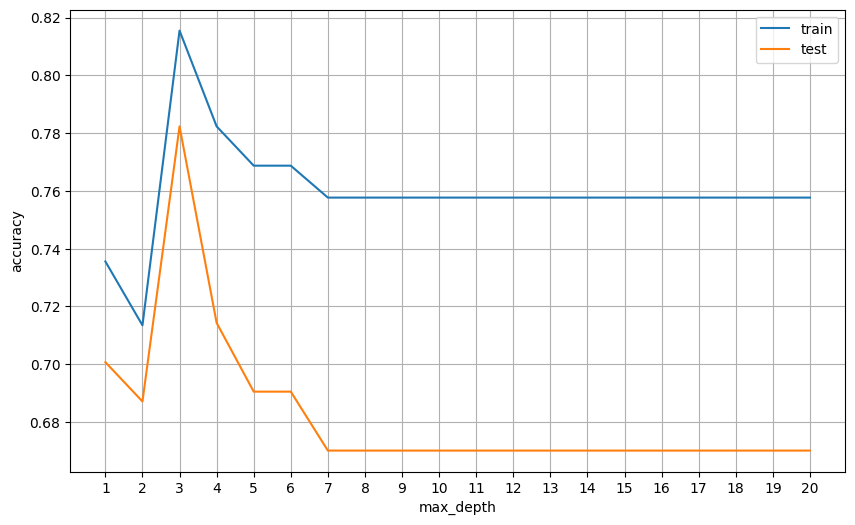

In [8]:

plt.figure(figsize = (10,6))

plt.plot(range(1,21),train_score, label = 'train')
plt.plot(range(1,21),test_score, label = 'test')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(range(1,21))
plt.legend()
plt.grid()
plt.show()

In [9]:
tree = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=30,
    class_weight='balanced',
    random_state=42
)

tree.fit(x_train, y_train)
train_pred = tree.predict(x_train)
test_pred = tree.predict(x_test)
train_f1 = f1_score(
    y_train,
    train_pred,
    pos_label='Yes'
)

test_f1 = f1_score(
    y_test,
    test_pred,
    pos_label='Yes'
)

print("Train F1:", train_f1)
print("Test F1:", test_f1)

Train F1: 0.5345454545454545
Test F1: 0.3225806451612903


In [10]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(
    strategy='most_frequent'
)

dummy.fit(x_train, y_train)

dummy_pred = dummy.predict(x_test)

dummy_f1 = f1_score(
    y_test,
    dummy_pred,
    pos_label='Yes'
)

tree_pred = tree.predict(x_test)

tree_f1 = f1_score(
    y_test,
    tree_pred,
    pos_label='Yes'
)

print("Dummy F1:", dummy_f1)
print("Tree F1 :", tree_f1)

Dummy F1: 0.0
Tree F1 : 0.3225806451612903


[Text(0.4791666666666667, 0.9, 'OverTime_Yes <= 0.5\ngini = 0.5\nsamples = 1176\nvalue = [588.0, 588.0]\nclass = No'),
 Text(0.1875, 0.7, 'TotalWorkingYears <= 2.5\ngini = 0.46\nsamples = 837\nvalue = [452.123, 252.424]\nclass = No'),
 Text(0.33333333333333337, 0.8, 'True  '),
 Text(0.08333333333333333, 0.5, 'StockOptionLevel <= 0.5\ngini = 0.414\nsamples = 76\nvalue = [30.663, 74.242]\nclass = Yes'),
 Text(0.041666666666666664, 0.3, 'gini = 0.324\nsamples = 43\nvalue = [14.429, 56.424]\nclass = Yes'),
 Text(0.125, 0.3, 'gini = 0.499\nsamples = 33\nvalue = [16.233, 17.818]\nclass = Yes'),
 Text(0.2916666666666667, 0.5, 'StockOptionLevel <= 0.5\ngini = 0.418\nsamples = 761\nvalue = [421.46, 178.182]\nclass = No'),
 Text(0.20833333333333334, 0.3, 'JobSatisfaction <= 1.5\ngini = 0.488\nsamples = 295\nvalue = [154.515, 112.848]\nclass = No'),
 Text(0.16666666666666666, 0.1, 'gini = 0.442\nsamples = 55\nvalue = [23.448, 47.515]\nclass = Yes'),
 Text(0.25, 0.1, 'gini = 0.444\nsamples = 240\n

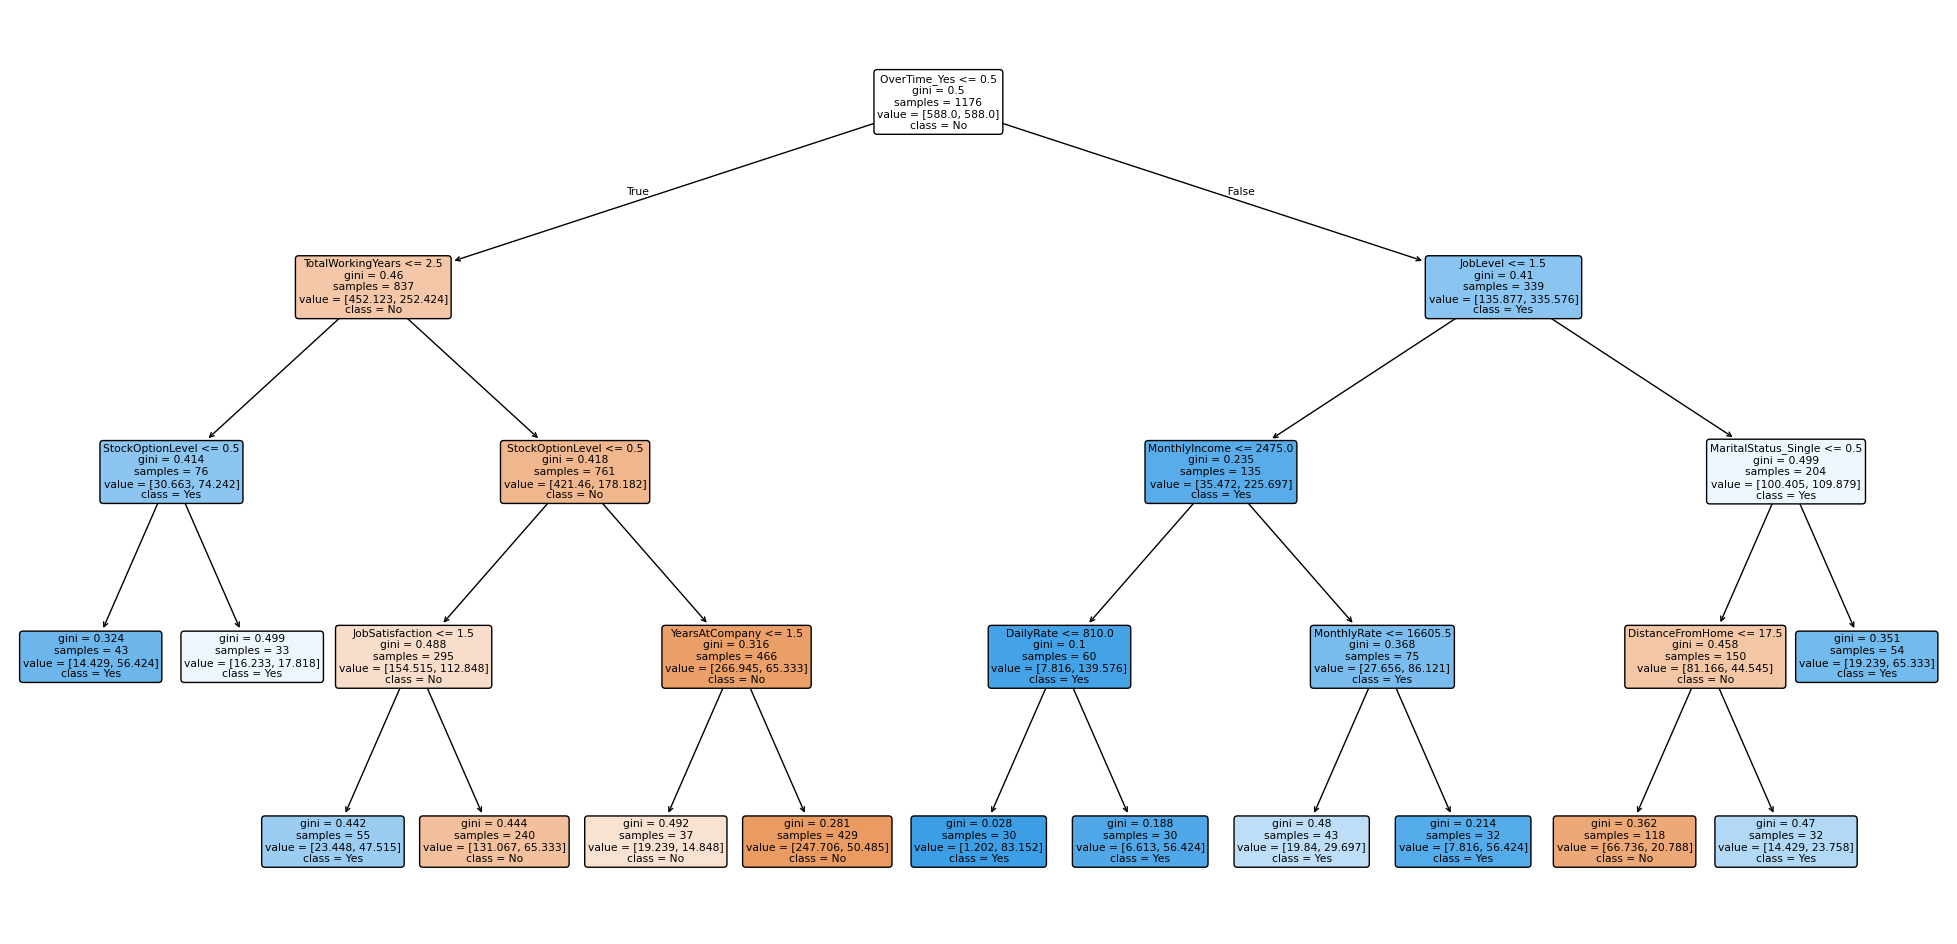

In [11]:
plt.figure(figsize = (25,12))

plot_tree(
    tree,
    feature_names = x_train.columns,
    class_names = ['No','Yes'],
    filled = True,
    rounded = True
)

In [12]:
rules = export_text(
    tree,
    feature_names = list(x_train.columns)
)

print(rules)

|--- OverTime_Yes <= 0.50
|   |--- TotalWorkingYears <= 2.50
|   |   |--- StockOptionLevel <= 0.50
|   |   |   |--- class: Yes
|   |   |--- StockOptionLevel >  0.50
|   |   |   |--- class: Yes
|   |--- TotalWorkingYears >  2.50
|   |   |--- StockOptionLevel <= 0.50
|   |   |   |--- JobSatisfaction <= 1.50
|   |   |   |   |--- class: Yes
|   |   |   |--- JobSatisfaction >  1.50
|   |   |   |   |--- class: No
|   |   |--- StockOptionLevel >  0.50
|   |   |   |--- YearsAtCompany <= 1.50
|   |   |   |   |--- class: No
|   |   |   |--- YearsAtCompany >  1.50
|   |   |   |   |--- class: No
|--- OverTime_Yes >  0.50
|   |--- JobLevel <= 1.50
|   |   |--- MonthlyIncome <= 2475.00
|   |   |   |--- DailyRate <= 810.00
|   |   |   |   |--- class: Yes
|   |   |   |--- DailyRate >  810.00
|   |   |   |   |--- class: Yes
|   |   |--- MonthlyIncome >  2475.00
|   |   |   |--- MonthlyRate <= 16605.50
|   |   |   |   |--- class: Yes
|   |   |   |--- MonthlyRate >  16605.50
|   |   |   |   |--- class: Y

In [13]:
importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': tree.feature_importances_
})

importance = importance.sort_values(
    'Importance',
    ascending=False
)

print(importance.head(10))

                 Feature  Importance
43          OverTime_Yes    0.357113
16     TotalWorkingYears    0.152264
7               JobLevel    0.137567
15      StockOptionLevel    0.093540
42  MaritalStatus_Single    0.089443
8        JobSatisfaction    0.059868
2       DistanceFromHome    0.039793
9          MonthlyIncome    0.023463
10           MonthlyRate    0.022003
19        YearsAtCompany    0.021946
